[*********************100%***********************]  9 of 9 completed

Fetching spot data for 9 pairs from 2021-01-01 to 2025-01-01...
Successfully fetched spot data.
Successfully calculated daily returns.
Starting optimized backtest over 790 days...


Backtest complete.


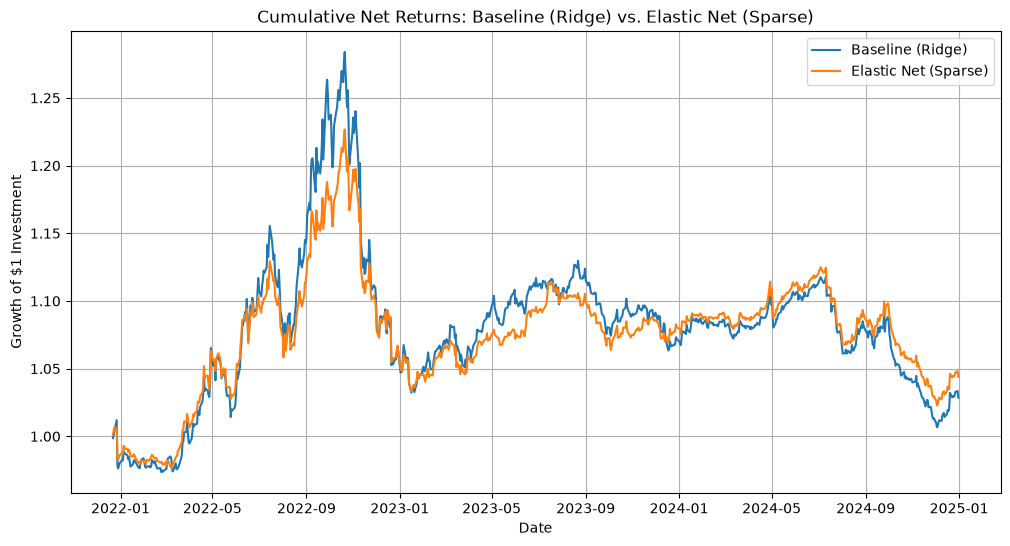

Baseline (Ridge) Sharpe Ratio: 0.09
Elastic Net (Sparse) Sharpe Ratio: 0.17
Results exported to backtest_results_2021-2025.csv. Analysis can be performed in Excel.


In [ ]:
# ==============================================================================
# MAIN BACKTESTING PIPELINE
# ==============================================================================
# This notebook coordinates the data loading, optimization, and backtesting 
# modules to evaluate the performance of our Elastic Net FX model.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import ForeignExchangeDataLoader
from backtester import FXBacktester

# 1. Configuration
# We use G10 currencies to test the model on a liquid, highly correlated universe.
tickers = ['EURUSD=X', 'JPY=X', 'GBPUSD=X', 'AUDUSD=X', 'CADUSD=X', 
           'CHFUSD=X', 'NZDUSD=X', 'SEKUSD=X', 'NOKUSD=X']
start_date = "2018-01-01"
end_date = "2023-01-01"

# 2. Data Ingestion
# Initialize the loader and calculate log returns.
loader = ForeignExchangeDataLoader(tickers=tickers, start_date=start_date, end_date=end_date)
loader.fetch_spot_data()
log_returns = loader.calculate_returns()

# 3. Execution
# Initialize the backtester with a 1-year window (252 days) and 2 basis point fee.
backtester = FXBacktester(returns_data=log_returns, window_size=252, transaction_cost_bps=2.0)
results = backtester.run_backtest()

# 4. Visualization & Performance Analysis
# Plot the cumulative returns to visualize alpha generation net-of-fees.
plt.figure(figsize=(12, 6))
for name, returns in results.items():
    cumulative_returns = returns.cumsum().apply(np.exp)
    plt.plot(cumulative_returns, label=name)

plt.title("Cumulative Net Returns: Baseline (Ridge) vs. Elastic Net (Sparse)")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)
plt.show()

# 5. Summary Statistics
# Calculate the Sharpe Ratio to quantify the risk-adjusted outperformance.
for name, returns in results.items():
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    print(f"{name} Sharpe Ratio: {sharpe:.2f}")

# 6. Export results for external analysis (since plot rendering is blocked)
results_df = pd.DataFrame(results)
results_df.to_csv("backtest_results_2021-2025.csv")
print("Results exported to backtest_results_2021-2025.csv. Analysis can be performed in Excel.")